## Project Description:

1.Who colloected it: The European Social Survey (ESS) is an academically driven cross-national survey that has been conducted across Europe since its establishment in 2001. 

2.How were respondants recurited:  The ESS uses cross-sectional, probability samples which are representative of all persons aged 15 and over resident within private households in each country.

3.Who funded this research: All participating countries are required to contribute to the central coordination costs, composed of a basic membership fee and an additional amount, calculated according to the GDP of each country. 

4.Where was this dataset deposited: The ESS data is available free of charge for non-commercial use and can be downloaded from the ESS Data Portal.

5.Why did they collect it: 
(1)operate a Research Infrastructure providing high quality data measuring change (and stability) over time within and between European countries in their living conditions, social structure, public opinion and attitudes
(2)practise and promote the highest scientific standards in cross-national comparative research in the social sciences;
(3)continue the development of ESS infrastructure through ongoing methodological research and innovation;
(4)facilitate training in the effective use of ESS data;
(5)ensure the visibility, accessibility and reach of ESS data among researchers in the social sciences and beyond, policy makers and the wider public, at both the national and international level.

6.What analyses/interpretations have been published already

7.What bias are introduced: Although the European Social Survey employs rigorous probability-based sampling and weighting procedures, some degree of non-response and social desirability bias is unavoidable, particularly for self-reported political behaviors. However, these biases are mitigated through ESS design and post-stratification weights, and are unlikely to substantially affect the estimated relationships between human values, socio-demographic characteristics, and boycott behavior.

8.Why not feature filtering: My goal is not to maximize predictive accuracy by testing all ESS variables, but to explain boycott behavior using theoretically grounded and interpretable predictors. The human values scale and basic socio-demographics are conceptually prior to the outcome, cross-nationally validated, and suitable for explainable ML. Using hundreds of variables would increase the risk of data dredging and undermine interpretability.

9.State of the art & gap: Existing research has largely relied on traditional regression-based models to examine associations between human values, socio-demographics, and boycott behavior, with limited use of machine learning methods that emphasize out-of-sample predictive performance, identify influential predictors, and explore potential non-linear relationships. 


## 1.1 Needed Packages

In [1]:
#Importing pakages

#Data Processing
import numpy as np
import pandas as pd

#Visualization
import seaborn as sns
import matplotlib.pyplot as plt

#Data processing modules
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

#Machine Learing Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC


## 1.2 Data Loading

In [2]:
data = 'ESS.csv'
df = pd.read_csv(data)
df_clean = df.drop(['name','essround','edition','proddate','idno','dweight','anweight','prob', 'stratum','psu','pspwght','pweight'], axis=1)
# Define missing value codes for each variable
missing_map = {
    'bctprd': [7, 8, 9],
    'gndr': [9],
    'agea': [999],
    'eduyrs': [77, 88, 99],
    'netusoft': [7,8,9],
    'nwspol': [7777,8888,9999]
}

# Variables with 66, 77, 88, 99 as missing
value_vars = ['ipcrtiva', 'impricha', 'ipeqopta', 'ipshabta', 'impsafea', 'impdiffa',
              'ipfrulea', 'ipudrsta', 'ipmodsta', 'ipgdtima', 'impfreea', 'iphlppla',
              'ipsucesa', 'ipstrgva', 'ipadvnta', 'ipbhprpa', 'iprspota', 'iplylfra',
              'impenva', 'imptrada', 'impfuna']

for var in value_vars:
    missing_map[var] = [66, 77, 88, 99]

# Replace defined missing codes with NaN
for col, codes in missing_map.items():
    df_clean[col] = df_clean[col].replace(codes, np.nan)

df_clean.rename(columns={'agea': 'age', 'nwspol':'news', 'eduyrs': 'education_years', 'gndr': 'gender', 'cntry':'country', 'bctprd':'boycott', 'netusoft': 'internet'}, inplace=True)

df_clean['boycott'] = df_clean['boycott'].replace(2, 0)
df_clean = df_clean.dropna(subset=['boycott'])


In [3]:
data = df_clean['news']

Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

outlier_percentage = (
    ((data < (Q1 - 1.5*IQR)) | (data > (Q3 + 1.5*IQR))).sum()
    / len(data) * 100
)

print(outlier_percentage)

5.854716299241056


In [4]:
df_clean['news'].describe()

count    49090.000000
mean        97.757547
std        159.101565
min          0.000000
25%         30.000000
50%         60.000000
75%        120.000000
max       1440.000000
Name: news, dtype: float64

In [5]:
# 1️⃣ 計算 99% 分位數
upper_99 = df_clean['news'].quantile(0.99)
print("99th percentile (upper limit):", upper_99)

# 2️⃣ 移除超過 99% 分位數的值
df_clean = df_clean[df_clean['news'] <= upper_99]

# 3️⃣ 查看清理後最大值和樣本數
max_value_after_clean = df_clean['news'].max()
remaining_samples = df_clean.shape[0]

print("Max value after removing extreme values:", max_value_after_clean)
print("Number of remaining samples:", remaining_samples)

99th percentile (upper limit): 941.3300000000017
Max value after removing extreme values: 941.0
Number of remaining samples: 48599


In [19]:
pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.5 MB 9.6 MB/s eta 0:00:01
   ----------------- ---------------------- 4.2/9.5 MB 12.0 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.5 MB 13.4 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 13.4 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 11.9 MB/s  0:00:00

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#explore dataset
print("\nShape of the dataset:", df_clean.shape)
print("\n", df_clean.info())


Shape of the dataset: (50116, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50116 entries, 0 to 50115
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          50116 non-null  object 
 1   news             49384 non-null  float64
 2   internet         50066 non-null  float64
 3   boycott          49806 non-null  float64
 4   gender           50116 non-null  int64  
 5   age              49723 non-null  float64
 6   education_years  49215 non-null  float64
 7   ipcrtiva         49190 non-null  float64
 8   impricha         49284 non-null  float64
 9   ipeqopta         49235 non-null  float64
 10  ipshabta         49210 non-null  float64
 11  impsafea         49328 non-null  float64
 12  impdiffa         49251 non-null  float64
 13  ipfrulea         48907 non-null  float64
 14  ipudrsta         49132 non-null  float64
 15  ipmodsta         49209 non-null  float64
 16  ipgdtima         49255 

In [ ]:
df_clean.head()

,country,news,internet,boycott,gender,age,education_years,ipcrtiva,impricha,ipeqopta,...,iphlppla,ipsucesa,ipstrgva,ipadvnta,ipbhprpa,iprspota,iplylfra,impenva,imptrada,impfuna
0,AT,90.0,5.0,2.0,1,65.0,12.0,3.0,5.0,2.0,...,2.0,3.0,2.0,5.0,2.0,2.0,2.0,2.0,3.0,3.0
1,AT,90.0,5.0,1.0,2,21.0,14.0,2.0,4.0,2.0,...,1.0,4.0,2.0,4.0,2.0,4.0,1.0,1.0,4.0,2.0
2,AT,30.0,5.0,1.0,2,53.0,16.0,1.0,4.0,1.0,...,1.0,3.0,2.0,4.0,3.0,3.0,1.0,1.0,3.0,2.0
3,AT,15.0,1.0,2.0,2,78.0,14.0,3.0,4.0,2.0,...,2.0,3.0,3.0,4.0,3.0,3.0,2.0,2.0,2.0,3.0
4,AT,60.0,5.0,2.0,1,64.0,12.0,3.0,4.0,2.0,...,2.0,2.0,2.0,4.0,2.0,2.0,2.0,2.0,2.0,2.0


In [ ]:
print(df_clean.describe())

               news      internet       boycott        gender           age  \
count  49384.000000  50066.000000  49806.000000  50116.000000  49723.000000   
mean      97.896323      4.198298      1.814741      1.539289     51.593749   
std      159.402172      1.419565      0.388511      0.498459     18.661027   
min        0.000000      1.000000      1.000000      1.000000     15.000000   
25%       30.000000      4.000000      2.000000      1.000000     37.000000   
50%       60.000000      5.000000      2.000000      2.000000     52.000000   
75%      120.000000      5.000000      2.000000      2.000000     67.000000   
max     1440.000000      5.000000      2.000000      2.000000     90.000000   

       education_years      ipcrtiva      impricha      ipeqopta  \
count     49215.000000  49190.000000  49284.000000  49235.000000   
mean         13.246957      2.622505      4.070327      2.051833   
std           4.018100      1.290409      1.360510      1.079070   
min           0.

In [ ]:

df_clean[['gender', 'boycott']] = df_clean[['gender', 'boycott']].astype('object')
numerical_cols = df_clean.select_dtypes(include = 'float64').columns
categorical_cols = df_clean.select_dtypes(include = 'object').columns

print(numerical_cols.values)
print(categorical_cols.values)



['news' 'internet' 'age' 'education_years' 'ipcrtiva' 'impricha'
 'ipeqopta' 'ipshabta' 'impsafea' 'impdiffa' 'ipfrulea' 'ipudrsta'
 'ipmodsta' 'ipgdtima' 'impfreea' 'iphlppla' 'ipsucesa' 'ipstrgva'
 'ipadvnta' 'ipbhprpa' 'iprspota' 'iplylfra' 'impenva' 'imptrada'
 'impfuna']
['country' 'boycott' 'gender']


## 1.3 EDA

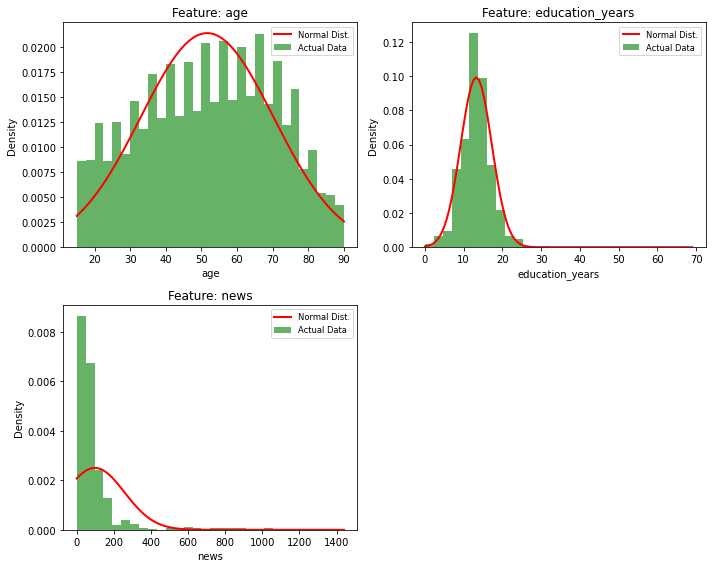

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math

# 1. Define  features 
selected_cols = ['age', 'education_years', 'news'] 
# If you want to run all numerical columns, use: selected_cols = numerical_cols

# 2. Calculate dynamic grid dimensions
n_features = len(selected_cols)
n_cols = 2  # You can change this to 3 or 4 for more columns
n_rows = math.ceil(n_features / n_cols)

# 3. Initialize the figure
fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))

# Ensure ax is an array even if there is only 1 plot
if n_features > 1:
    ax = ax.flatten()
else:
    ax = [ax]

# 4. Loop through each feature to create the plots
for c, column in enumerate(selected_cols):
    # Calculate mean (mu) and standard deviation (sigma)
    mu, sigma = X[column].mean(), X[column].std()
    
    # Plot Histogram: density=True normalizes the y-axis to total 1 (Density)
    # Using 20-30 bins is standard for seeing the distribution shape
    count, bins_edges, ignored = ax[c].hist(X[column], bins=30, density=True, 
                                            alpha=0.6, color='g', label='Actual Data')

    # Generate smooth X-values for the Normal Distribution curve
    # This prevents the "jagged" red line seen when using histogram bins
    x_smooth = np.linspace(X[column].min(), X[column].max(), 100)
    
    # Calculate the Probability Density Function (PDF)
    pdf = 1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-(x_smooth - mu) ** 2 / (2 * sigma ** 2))
    
    # Plot the Normal Distribution curve
    ax[c].plot(x_smooth, pdf, linewidth=2, color='r', label='Normal Dist.')

    # Formatting
    ax[c].set_title(f'Feature: {column}')
    ax[c].set_xlabel(column)
    ax[c].set_ylabel('Density')
    ax[c].legend(fontsize='small')

# 5. Hide unused axes (if n_features < total grid slots)
for i in range(n_features, len(ax)):
    ax[i].axis('off')

# 6. Final layout and save
plt.tight_layout()
plt.show()

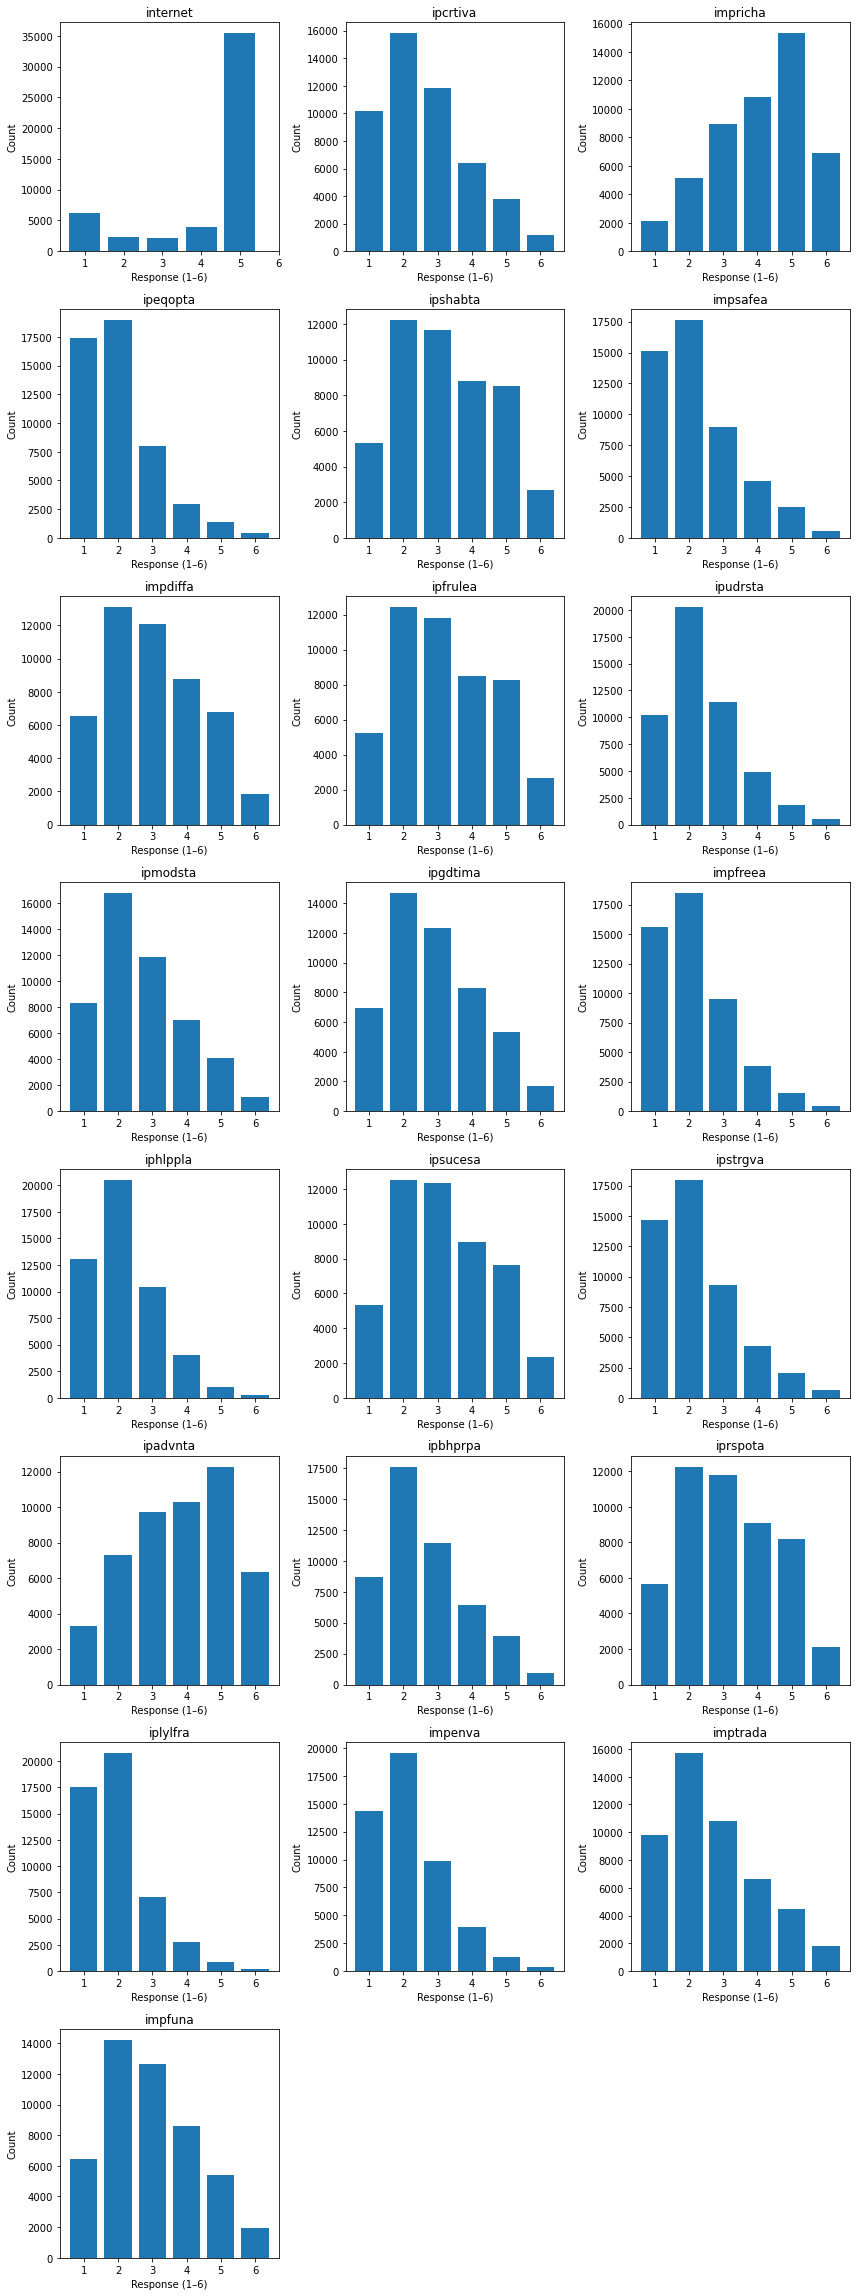

In [ ]:

# Drop continuous variables
likert_cols = [c for c in numerical_cols if c not in ['age', 'education_years', 'news']]

n_cols = 3
n_rows = int(np.ceil(len(likert_cols) / n_cols))

fig, ax = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
ax = ax.flatten()

for i, column in enumerate(likert_cols):

    counts = X[column].value_counts().sort_index()

    ax[i].bar(counts.index, counts.values)
    ax[i].set_title(column)
    ax[i].set_xlabel('Response (1–6)')
    ax[i].set_ylabel('Count')
    ax[i].set_xticks(range(1, 7))

# Delete extra empty plots
for j in range(i + 1, len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
#plt.savefig('Likert_21_item_counts.pdf', dpi=300)


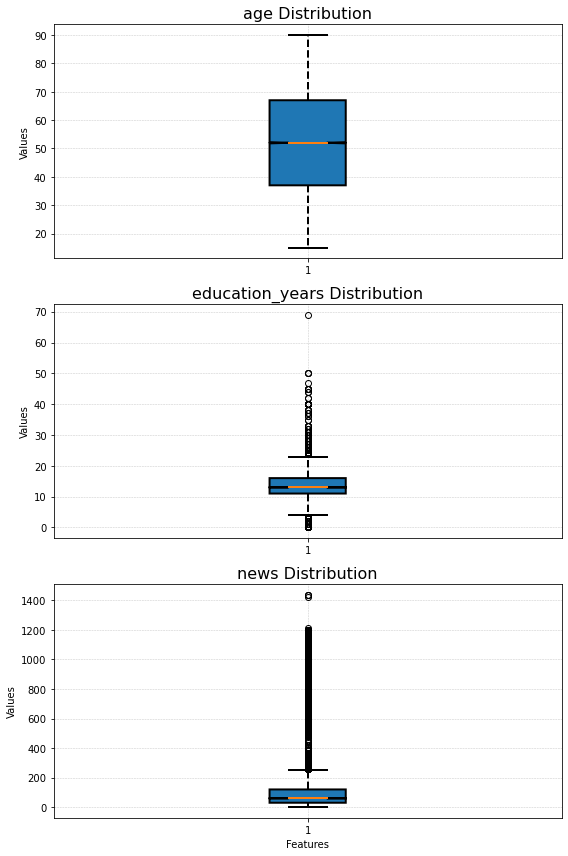

In [ ]:
box_cols = ['age', 'education_years', 'news']

# Convert to numeric + drop missing values
box_data = X[box_cols].apply(pd.to_numeric, errors='coerce').dropna()

fig, axes = plt.subplots(3, 1, figsize=(8, 12))

boxprops = dict(linestyle='-', linewidth=2)
medianprops = dict(linestyle='-', linewidth=2)
whiskerprops = dict(linestyle='--', linewidth=2)
capprops = dict(linestyle='-', linewidth=2)

for i, col in enumerate(box_cols):
    axes[i].boxplot(
        box_data[col].values,
        notch=True,
        patch_artist=True,
        boxprops=boxprops,
        medianprops=medianprops,
        whiskerprops=whiskerprops,
        capprops=capprops
    )

    axes[i].set_title(f'{col} Distribution', fontsize=16)
    axes[i].set_ylabel('Values')
    axes[i].grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

axes[-1].set_xlabel('Features')

plt.tight_layout()
plt.show()
#plt.savefig('Age_Eduyrs_boxplot.pdf', dpi=300)



In [ ]:
import pandas as pd

# Example DataFrame
# df = pd.read_csv("your_data.csv")  # if reading from CSV

# Calculate Q1, Q3 and IQR
Q1 = df_clean['education_years'].quantile(0.25)
Q3 = df_clean['education_years'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df_clean[(df_clean['education_years'] < lower_bound) | (df_clean['education_years'] > upper_bound)]

# Calculate outlier percentage
outlier_percent = (len(outliers) / len(df_clean)) * 100

print(f"Outlier percentage for eduyrs: {outlier_percent:.2f}%")


Outlier percentage for eduyrs: 1.87%


In [ ]:
import pandas as pd

# Example DataFrame
# df = pd.read_csv("your_data.csv")  # if reading from CSV

# Calculate Q1, Q3 and IQR
Q1 = df_clean['news'].quantile(0.25)
Q3 = df_clean['news'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(lower_bound, upper_bound)
# Identify outliers
outliers = df_clean[(df_clean['news'] < lower_bound) | (df_clean['news'] > upper_bound)]

# Calculate outlier percentage
outlier_percent = (len(outliers) / len(df_clean)) * 100

print(f"Outlier percentage for news: {outlier_percent:.2f}%")


0.0 0.0
Outlier percentage for news: 0.00%


In [ ]:
# 1️⃣ 計算 99% 分位數
upper_99 = df_clean['news'].quantile(0.99)
print("99th percentile (upper limit):", upper_99)

# 2️⃣ 移除超過 99% 分位數的值
df_clean = df_clean[df_clean['news'] <= upper_99]

# 3️⃣ 查看清理後最大值和樣本數
max_value_after_clean = df_clean['news'].max()
remaining_samples = df_clean.shape[0]

print("Max value after removing extreme values:", max_value_after_clean)
print("Number of remaining samples:", remaining_samples)

99th percentile (upper limit): 0.0
Max value after removing extreme values: 0.0
Number of remaining samples: 3496


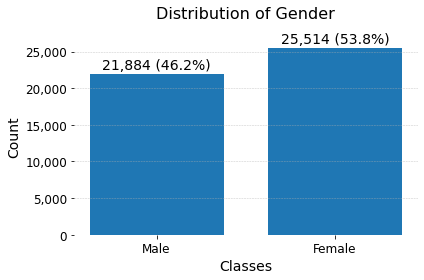

In [ ]:
# Count samples in each class (bctprd = 1 or 2)
class_counts = [
    np.sum(df_clean['gender'] == 1),
    np.sum(df_clean['gender'] == 2)
]

class_labels = ['Male', 'Female']

# Calculate percentages
total = sum(class_counts)
class_percents = [(count / total) * 100 for count in class_counts]

# Bar Plot
plt.figure(figsize=(6, 4))
bars = plt.bar(class_labels, class_counts, width=0.75)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7, axis='y')

# Title and labels
plt.title('Distribution of Gender', fontsize=16, pad=20)  # space above bars
plt.xlabel('Classes', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add value labels above the bars with count and percentage
for bar, percent in zip(bars, class_percents):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + max(class_counts)*0.01,  # slightly above the bar
        f"{int(yval):,} ({percent:.1f}%)",  # count with thousands separator and %
        ha='center',
        va='bottom',
        fontsize=14
    )

# Format y-axis with thousands separator
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Remove spines
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
#plt.savefig('gender_class_dist.pdf', dpi=300)
plt.show()


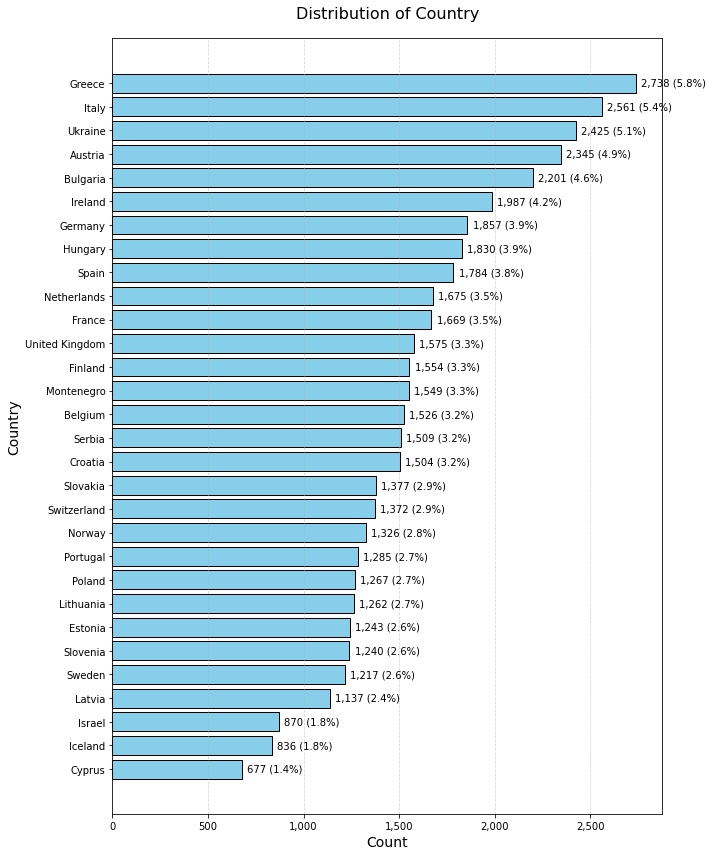

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# List of country codes and labels
countries = [
    'AT','BE','BG','CH','CY','DE','EE','ES','FI','FR','GB','GR','HR',
    'HU','IE','IS','IL','IT','LT','LV','ME','NL','NO','PL','PT','RS',
    'SE','SI','SK','UA'
]

country_labels = [
    'Austria','Belgium','Bulgaria','Switzerland','Cyprus','Germany',
    'Estonia','Spain','Finland','France','United Kingdom','Greece','Croatia','Hungary',
    'Ireland','Iceland','Israel','Italy','Lithuania','Latvia','Montenegro','Netherlands',
    'Norway','Poland','Portugal','Serbia',
    'Sweden','Slovenia','Slovakia','Ukraine'
]

# Compute counts
class_counts = [np.sum(df_clean['country'] == c) for c in countries]
total = sum(class_counts)
class_percents = [(count / total) * 100 for count in class_counts]

# Sort from lowest to highest
sorted_idx = np.argsort(class_counts)
sorted_counts = [class_counts[i] for i in sorted_idx]
sorted_labels = [country_labels[i] for i in sorted_idx]
sorted_percents = [class_percents[i] for i in sorted_idx]

# Horizontal bar plot
plt.figure(figsize=(10, 12))
bars = plt.barh(sorted_labels, sorted_counts, color='skyblue', edgecolor='black')

plt.xlabel('Count', fontsize=14)
plt.ylabel('Country', fontsize=14)
plt.title('Distribution of Country', fontsize=16, pad=20)
plt.grid(True, axis='x', linestyle='--', alpha=0.5)

# Add value labels with count and percentage
for bar, percent in zip(bars, sorted_percents):
    width = bar.get_width()
    plt.text(
        width + max(sorted_counts)*0.01,
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,} ({percent:.1f}%)",
        va='center',
        fontsize=10
    )

# Format x-axis with thousands separator
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
#plt.savefig('country_class_dist_horizontal.pdf', dpi=300)
plt.show()


In [ ]:
df['cntry'].nunique()

30

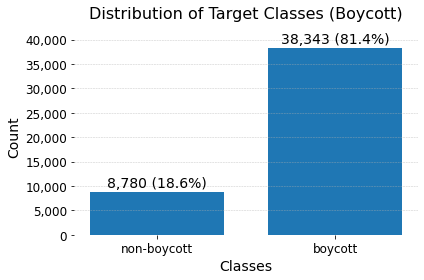

In [ ]:
# Count samples in each class (bctprd = 1 or 2)
class_counts = [
    np.sum(df_clean['boycott'] == 1),
    np.sum(df_clean['boycott'] == 2)
]

class_labels = ['non-boycott', 'boycott']

# Calculate percentages
total = sum(class_counts)
class_percents = [(count / total) * 100 for count in class_counts]

# Bar Plot
plt.figure(figsize=(6, 4))
bars = plt.bar(class_labels, class_counts, width=0.75)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7, axis='y')

# Title and labels
plt.title('Distribution of Target Classes (Boycott)', fontsize=16, pad=20)  # space above bars
plt.xlabel('Classes', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add value labels above the bars with count and percentage
for bar, percent in zip(bars, class_percents):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + max(class_counts)*0.01,  # slightly above the bar
        f"{int(yval):,} ({percent:.1f}%)",  # count with thousands separator and %
        ha='center',
        va='bottom',
        fontsize=14
    )

# Format y-axis with thousands separator
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Remove spines
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
#plt.savefig('bctprd_class_dist.pdf', dpi=300)
plt.show()


<Figure size 864x720 with 0 Axes>

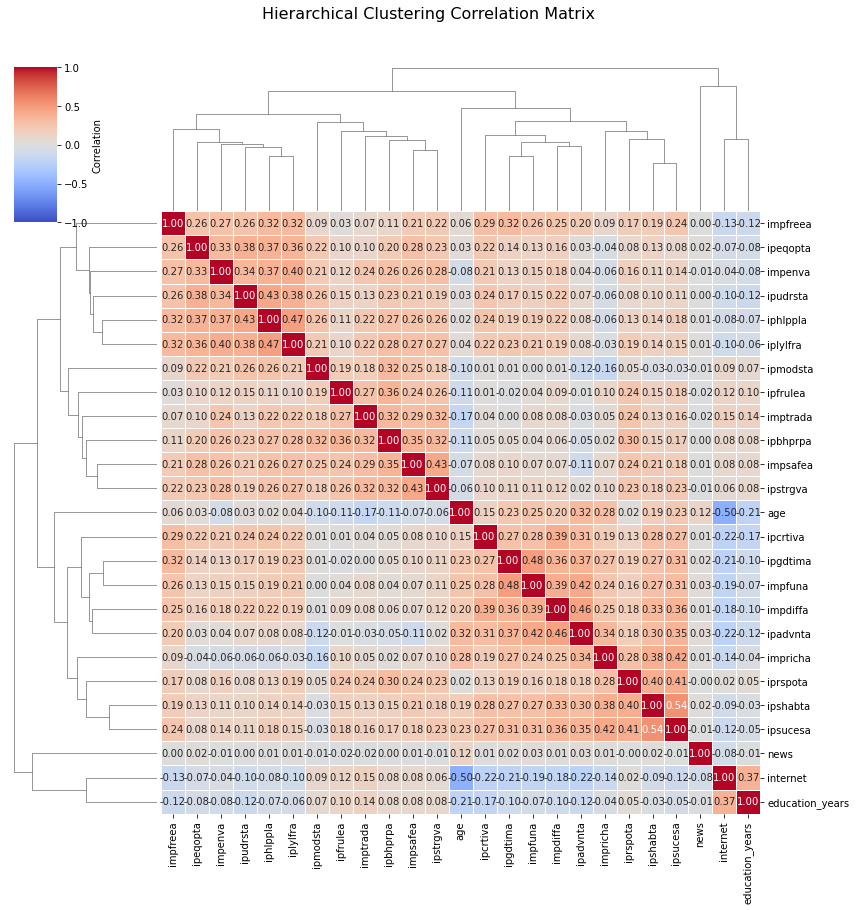

Is there any correlation > 0.6? False


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 計算相關矩陣
correlation_matrix = df_clean[numerical_cols].corr()

# 畫階層聚類相關矩陣
plt.figure(figsize=(12, 10))
sns.clustermap(
    correlation_matrix,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    figsize=(12, 12),
    cbar_kws={"label": "Correlation"},
    vmax=1,
    vmin=-1
)
plt.suptitle('Hierarchical Clustering Correlation Matrix', fontsize=16, y=1.05)
#plt.savefig('Correlation_heatmap_clustered.pdf', dpi=300, bbox_inches='tight')
plt.show()
np.fill_diagonal(correlation_matrix.values, 0)  # 先把對角線設為 0
high_corr = (correlation_matrix > 0.6).any().any()

print("Is there any correlation > 0.6?", high_corr)

In [ ]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# X 是 numerical features
X = df_clean[numerical_cols].dropna()  # 刪掉含 NaN 的 row

# 計算 VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

            feature        VIF
0              news   1.397306
1          internet  11.460415
2               age  10.163535
3   education_years  13.057208
4          ipcrtiva   6.970500
5          impricha  14.364204
6          ipeqopta   6.346727
7          ipshabta  10.281350
8          impsafea   6.852621
9          impdiffa   9.266015
10         ipfrulea   7.876278
11         ipudrsta   8.323230
12         ipmodsta   6.949582
13         ipgdtima   8.806337
14         impfreea   6.514985
15         iphlppla   9.051426
16         ipsucesa  11.250173
17         ipstrgva   6.670485
18         ipadvnta  12.757658
19         ipbhprpa   8.094317
20         iprspota   8.980859
21         iplylfra   8.001287
22          impenva   7.262287
23         imptrada   6.570605
24          impfuna   9.172740


In [ ]:

# Define missing value codes for each variable
missing_map = {
    'bctprd': [7, 8, 9],
    'gndr': [9],
    'agea': [999],
    'eduyrs': [77, 88, 99],
}

# Variables with 66, 77, 88, 99 as missing
value_vars = ['ipcrtiva', 'impricha', 'ipeqopta', 'ipshabta', 'impsafea', 'impdiffa',
              'ipfrulea', 'ipudrsta', 'ipmodsta', 'ipgdtima', 'impfreea', 'iphlppla',
              'ipsucesa', 'ipstrgva', 'ipadvnta', 'ipbhprpa', 'iprspota', 'iplylfra',
              'impenva', 'imptrada', 'impfuna']

for var in value_vars:
    missing_map[var] = [66, 77, 88, 99]

# Replace defined missing codes with NaN
for col, codes in missing_map.items():
    df[col] = df[col].replace(codes, pd.NA)

# Count rows with any missing values
missing_rows = df.isna().any(axis=1).sum()

# Total rows before dropping
total_rows = len(df)

# Percentage of rows with missing values
missing_percentage = (missing_rows / total_rows) * 100
print(f"Rows with missing values: {missing_rows} / {total_rows} ({missing_percentage:.2f}%)")

# Remove rows with any missing values
df_clean = df.dropna()

# Optional: check new row count
print(f"Rows after removing missing values: {len(df_clean)}")


Rows with missing values: 5082 / 50116 (10.14%)
Rows after removing missing values: 45034


In [ ]:
missing_per_var = df.isna().mean() * 100
print(missing_per_var.sort_values(ascending=False))


ipfrulea    2.412403
ipstrgva    2.346556
iprspota    2.091149
ipudrsta    1.963445
ipsucesa    1.961449
ipbhprpa    1.933514
ipcrtiva    1.847713
ipmodsta    1.809801
ipshabta    1.807806
ipadvnta    1.803815
eduyrs      1.797829
ipeqopta    1.757922
impfuna     1.745949
impdiffa    1.725996
imptrada    1.718014
ipgdtima    1.718014
impenva     1.680102
iplylfra    1.664139
impricha    1.660148
impfreea    1.646181
iphlppla    1.610264
impsafea    1.572352
agea        0.784181
bctprd      0.618565
prob        0.000000
stratum     0.000000
name        0.000000
essround    0.000000
gndr        0.000000
badge       0.000000
anweight    0.000000
pweight     0.000000
pspwght     0.000000
dweight     0.000000
cntry       0.000000
idno        0.000000
proddate    0.000000
edition     0.000000
psu         0.000000
dtype: float64


Missing % per variable:
ipfrulea    2.412403
ipstrgva    2.346556
iprspota    2.091149
ipudrsta    1.963445
ipsucesa    1.961449
ipbhprpa    1.933514
ipcrtiva    1.847713
ipmodsta    1.809801
ipshabta    1.807806
ipadvnta    1.803815
eduyrs      1.797829
ipeqopta    1.757922
impfuna     1.745949
impdiffa    1.725996
imptrada    1.718014
ipgdtima    1.718014
impenva     1.680102
iplylfra    1.664139
impricha    1.660148
impfreea    1.646181
iphlppla    1.610264
impsafea    1.572352
agea        0.784181
bctprd      0.618565
prob        0.000000
stratum     0.000000
name        0.000000
essround    0.000000
gndr        0.000000
badge       0.000000
anweight    0.000000
pweight     0.000000
pspwght     0.000000
dweight     0.000000
cntry       0.000000
idno        0.000000
proddate    0.000000
edition     0.000000
psu         0.000000
dtype: float64


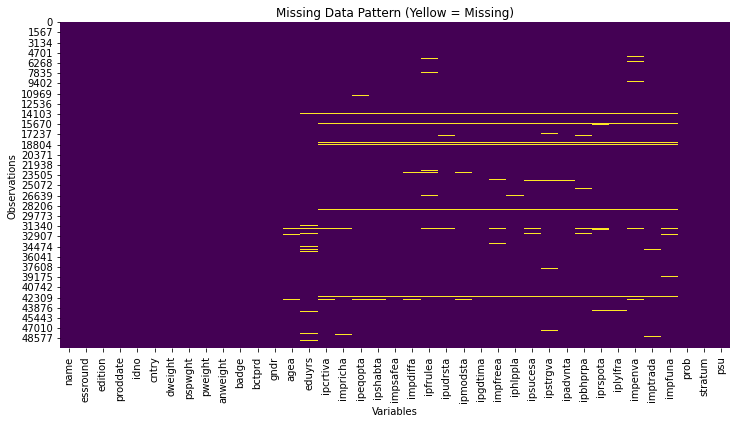

Missing % per variable:
ipfrulea    2.412403
ipstrgva    2.346556
iprspota    2.091149
ipudrsta    1.963445
ipsucesa    1.961449
ipbhprpa    1.933514
ipcrtiva    1.847713
ipmodsta    1.809801
ipshabta    1.807806
ipadvnta    1.803815
eduyrs      1.797829
ipeqopta    1.757922
impfuna     1.745949
impdiffa    1.725996
imptrada    1.718014
ipgdtima    1.718014
impenva     1.680102
iplylfra    1.664139
impricha    1.660148
impfreea    1.646181
iphlppla    1.610264
impsafea    1.572352
agea        0.784181
bctprd      0.618565
prob        0.000000
stratum     0.000000
name        0.000000
essround    0.000000
gndr        0.000000
badge       0.000000
anweight    0.000000
pweight     0.000000
pspwght     0.000000
dweight     0.000000
cntry       0.000000
idno        0.000000
proddate    0.000000
edition     0.000000
psu         0.000000
dtype: float64


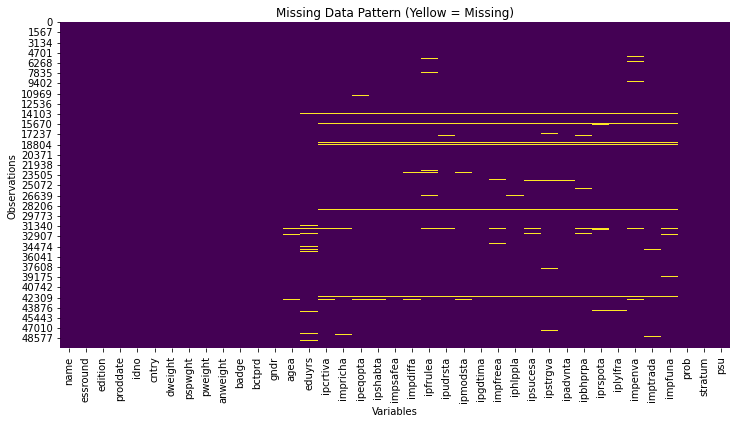

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Example: your dataframe
# df = pd.read_csv('your_data.csv')

# Define missing codes
missing_map = {
    'bctprd': [7, 8, 9],
    'gndr': [9],
    'agea': [999],
    'eduyrs': [77, 88, 99],
}

# Variables with 66, 77, 88, 99 as missing
value_vars = ['ipcrtiva', 'impricha', 'ipeqopta', 'ipshabta', 'impsafea', 'impdiffa',
              'ipfrulea', 'ipudrsta', 'ipmodsta', 'ipgdtima', 'impfreea', 'iphlppla',
              'ipsucesa', 'ipstrgva', 'ipadvnta', 'ipbhprpa', 'iprspota', 'iplylfra',
              'impenva', 'imptrada', 'impfuna']

for var in value_vars:
    missing_map[var] = [66, 77, 88, 99]

# 1. Replace all missing codes with NaN
df_copy = df.copy()
for col, missing_vals in missing_map.items():
    df_copy[col] = df_copy[col].replace(missing_vals, pd.NA)

# 2. Calculate % missing per variable
missing_percent = df_copy.isna().mean() * 100
print("Missing % per variable:")
print(missing_percent.sort_values(ascending=False))


# 3. Visualize missing pattern
plt.figure(figsize=(12,6))
sns.heatmap(df_copy.isna(), cbar=False, cmap='viridis')
plt.title('Missing Data Pattern (Yellow = Missing)')
plt.xlabel('Variables')
plt.ylabel('Observations')
plt.show()


# Example: your dataframe
# df = pd.read_csv('your_data.csv')

# Define missing codes
missing_map = {
    'bctprd': [7, 8, 9],
    'gndr': [9],
    'agea': [999],
    'eduyrs': [77, 88, 99],
}

# Variables with 66, 77, 88, 99 as missing
value_vars = ['ipcrtiva', 'impricha', 'ipeqopta', 'ipshabta', 'impsafea', 'impdiffa',
              'ipfrulea', 'ipudrsta', 'ipmodsta', 'ipgdtima', 'impfreea', 'iphlppla',
              'ipsucesa', 'ipstrgva', 'ipadvnta', 'ipbhprpa', 'iprspota', 'iplylfra',
              'impenva', 'imptrada', 'impfuna']

for var in value_vars:
    missing_map[var] = [66, 77, 88, 99]

# 1. Replace all missing codes with NaN
df_copy = df.copy()
for col, missing_vals in missing_map.items():
    df_copy[col] = df_copy[col].replace(missing_vals, pd.NA)

# 2. Calculate % missing per variable
missing_percent = df_copy.isna().mean() * 100
print("Missing % per variable:")
print(missing_percent.sort_values(ascending=False))

# 3. Visualize missing pattern
plt.figure(figsize=(12,6))
sns.heatmap(df_copy.isna(), cbar=False, cmap='viridis')
plt.title('Missing Data Pattern (Yellow = Missing)')
plt.xlabel('Variables')
plt.ylabel('Observations')
plt.show()


Missing % per variable:
ipfrulea    2.412403
ipstrgva    2.346556
iprspota    2.091149
ipudrsta    1.963445
ipsucesa    1.961449
ipbhprpa    1.933514
ipcrtiva    1.847713
ipmodsta    1.809801
ipshabta    1.807806
ipadvnta    1.803815
eduyrs      1.797829
ipeqopta    1.757922
impfuna     1.745949
impdiffa    1.725996
ipgdtima    1.718014
imptrada    1.718014
impenva     1.680102
iplylfra    1.664139
impricha    1.660148
impfreea    1.646181
iphlppla    1.610264
impsafea    1.572352
agea        0.784181
bctprd      0.618565
gndr        0.000000
dtype: float64


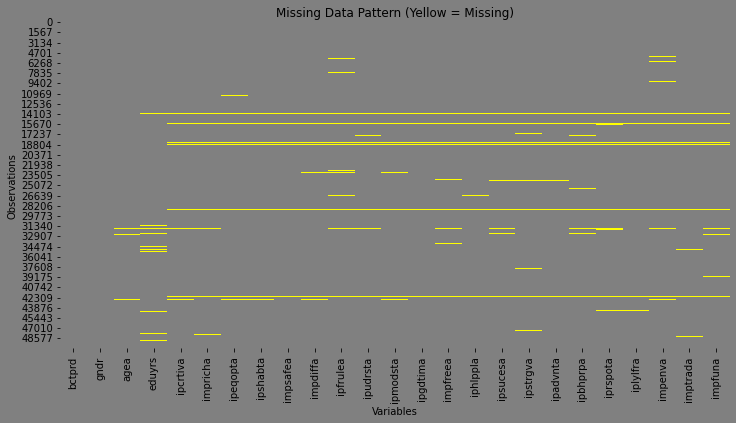

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# 假設 df 已經存在
# df = pd.read_csv('your_data.csv')

# Define missing codes
missing_map = {
    'bctprd': [7, 8, 9],
    'gndr': [9],
    'agea': [999],
    'eduyrs': [77, 88, 99],
}

# Variables with 66, 77, 88, 99 as missing
value_vars = ['ipcrtiva', 'impricha', 'ipeqopta', 'ipshabta', 'impsafea', 'impdiffa',
              'ipfrulea', 'ipudrsta', 'ipmodsta', 'ipgdtima', 'impfreea', 'iphlppla',
              'ipsucesa', 'ipstrgva', 'ipadvnta', 'ipbhprpa', 'iprspota', 'iplylfra',
              'impenva', 'imptrada', 'impfuna']

for var in value_vars:
    missing_map[var] = [66, 77, 88, 99]

# 1. Replace all missing codes with NaN
df_copy = df.copy()
for col, missing_vals in missing_map.items():
    df_copy[col] = df_copy[col].replace(missing_vals, pd.NA)

# 2. Calculate % missing per variable (only the columns you care about)
missing_percent = df_copy[list(missing_map.keys())].isna().mean() * 100
print("Missing % per variable:")
print(missing_percent.sort_values(ascending=False))

# 3. Visualize missing pattern for only those columns
plt.figure(figsize=(12,6), facecolor='gray')
cmap = ListedColormap(['gray', 'yellow'])  # 非缺失值白色，缺失值黃色

# 只選擇 missing_map 的欄位
ax = sns.heatmap(df_copy[list(missing_map.keys())].isna(), cbar=False, cmap=cmap)
ax.set_facecolor('grey')  # heatmap 背景白色
plt.title('Missing Data Pattern (Yellow = Missing)')
plt.xlabel('Variables')
plt.ylabel('Observations')
plt.show()


In [ ]:
#EDA
# age
print(f"age%: \n{df['agea'].value_counts(normalize=True).get(999)}")

#gender
print(f"gender% : \n {df['gndr'].value_counts(normalize=True)}")

#eduyrs
print(f"education% : \n {df['eduyrs'].value_counts(normalize=True)[[77, 88, 99]]}")

print(df['eduyrs'].isin([77,88,99]).mean())

age%: 
None
gender% : 
 2    0.539289
1    0.460711
Name: gndr, dtype: float64


KeyError: "None of [Int64Index([77, 88, 99], dtype='int64')] are in the [index]"

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

#laoding DF
df = pd.read_csv('ESS.csv')


#remove surplus columns
df_clean = df.drop(['name','essround','edition','proddate','idno','dweight','anweight','badge','prob', 'stratum','psu','pspwght','pweight'], axis=1)

#map missing values & clean up missing value

human_value_cols = ['ipcrtiva','impfreea','impdiffa','iplylfra','ipgdtima','impfuna',
                    'ipshabta','ipadvnta','impricha','ipsucesa','iprspota','impsafea','impenva',
                    'ipfrulea','ipudrsta','ipmodsta','imptrada','ipstrgva','ipbhprpa','ipeqopta','iphlppla']

hv_missing_vals = [66, 77, 88, 99]

for col in human_value_cols:
    df_clean[col]=df_clean[col].replace(hv_missing_vals, np.nan)

df_clean ['bctprd'] = df_clean ['bctprd'].replace([7,8,9], np.nan)
df_clean ['gndr']   = df_clean ['gndr'].replace([9], np.nan)
df_clean ['agea']   = df_clean ['agea'].replace([999], np.nan)
df_clean ['eduyrs'] = df_clean ['eduyrs'].replace([77,88,99], np.nan)

df_clean = df_clean.dropna(axis=0, thresh=0.2*df.shape[1])


#MI
cols_to_impute = df_clean.columns.drop('cntry')
imputer = IterativeImputer(max_iter=10, random_state=42)
df_clean[cols_to_impute] = imputer.fit_transform(df_clean[cols_to_impute])

#rename columns 
df_clean=df_clean.rename(columns={'bctprd':'boycott', 'gndr':'gender', 'agea':'age','cntry':'country'})
df_clean['boycott']=df_clean['boycott'].replace({2:0})


#aggregating
df_clean['selfDirection'] = df_clean[['ipcrtiva','impfreea']].mean(axis=1)
df_clean['stimulation'] = df_clean[['impdiffa','iplylfra']].mean(axis=1)
df_clean['hedonism'] = df_clean[['ipgdtima','impfuna']].mean(axis=1)
df_clean['achievement'] = df_clean[['ipshabta','ipadvnta']].mean(axis=1)
df_clean['power'] = df_clean[['impricha','ipsucesa','iprspota']].mean(axis=1)
df_clean['security'] = df_clean[['impsafea','impenva']].mean(axis=1)
df_clean['conformity'] = df_clean['ipfrulea']  # only one item
df_clean['tradition'] = df_clean[['ipudrsta','ipmodsta','imptrada']].mean(axis=1)
df_clean['benevolence'] = df_clean[['ipstrgva','ipbhprpa']].mean(axis=1)
df_clean['universalism'] = df_clean[['ipeqopta','iphlppla']].mean(axis=1)

#one-hot

#define target, featuers
target = df_clean['boycott']
print(target.value_counts())

0.000000    40175
1.000000     9097
2.103126        1
1.898503        1
1.857447        1
            ...  
1.809158        1
1.771393        1
1.880695        1
1.946689        1
1.842590        1
Name: boycott, Length: 304, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


#laoding DF
df = pd.read_csv('ESS.csv')




#remove surplus columns
df_clean = df.drop(['name','essround','edition','proddate','idno','dweight','anweight','badge','prob', 'stratum','psu','pspwght','pweight'], axis=1)
#rename columns 
df_clean=df_clean.rename(columns={'bctprd':'boycott', 'gndr':'gender', 'agea':'age','cntry':'country'})
df_clean['boycott']=df_clean['boycott'].replace({2:0})
df_clean = df_clean[df_clean['boycott'].isin([0,1])]
#map missing values & clean up missing value

human_value_cols = ['ipcrtiva','impfreea','impdiffa','iplylfra','ipgdtima','impfuna',
                    'ipshabta','ipadvnta','impricha','ipsucesa','iprspota','impsafea','impenva',
                    'ipfrulea','ipudrsta','ipmodsta','imptrada','ipstrgva','ipbhprpa','ipeqopta','iphlppla']

hv_missing_vals = [66, 77, 88, 99]

for col in human_value_cols:
    df_clean[col]=df_clean[col].replace(hv_missing_vals, np.nan)

df_clean ['gender']   = df_clean ['gender'].replace([9], np.nan)
df_clean ['age']   = df_clean ['age'].replace([999], np.nan)
df_clean ['eduyrs'] = df_clean ['eduyrs'].replace([77,88,99], np.nan)

df_clean = df_clean.dropna(axis=0, thresh=0.2*df.shape[1])


#MI
cols_to_impute = df_clean.columns.drop('country','boycott')
imputer = IterativeImputer(max_iter=10, random_state=42)
df_clean[cols_to_impute] = imputer.fit_transform(df_clean[cols_to_impute])


print(df_clean['boycott'].dtype)
print(df_clean['boycott'].unique())


float64
[0. 1.]


/Users/ting/opt/anaconda3/lib/python3.9/site-packages/sklearn/impute/_iterative.py:699: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Baseline - Accuracy: 0.815, F1: 0.000, PR-AUC: 0.185
Logistic Regression - Accuracy: 0.718, F1: 0.476, PR-AUC: 0.470
Random Forest - Accuracy: 0.830, F1: 0.246, PR-AUC: 0.479


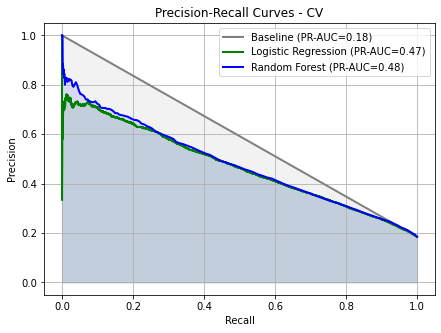

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_curve, average_precision_score, accuracy_score, f1_score

# =========================
# Load and clean dataset
# =========================
df = pd.read_csv('ESS.csv')
drop_cols = ['name','essround','edition','proddate','idno','dweight','anweight',
             'badge','prob', 'stratum','psu','pspwght','pweight']
df_clean = df.drop(drop_cols, axis=1)
df_clean = df_clean.rename(columns={'bctprd':'boycott', 'gndr':'gender', 'agea':'age','cntry':'country'})
df_clean['boycott'] = df_clean['boycott'].replace({2:0})
df_clean = df_clean[df_clean['boycott'].isin([0,1])]

human_value_cols = ['ipcrtiva','impfreea','impdiffa','iplylfra','ipgdtima','impfuna',
                    'ipshabta','ipadvnta','impricha','ipsucesa','iprspota','impsafea',
                    'impenva','ipfrulea','ipudrsta','ipmodsta','imptrada','ipstrgva',
                    'ipbhprpa','ipeqopta','iphlppla']
hv_missing_vals = [66, 77, 88, 99]

for col in human_value_cols:
    df_clean[col] = df_clean[col].replace(hv_missing_vals, np.nan)

df_clean['gender'] = df_clean['gender'].replace([9], np.nan)
df_clean['age'] = df_clean['age'].replace([999], np.nan)
df_clean['eduyrs'] = df_clean['eduyrs'].replace([77,88,99], np.nan)
df_clean = df_clean.dropna(axis=0, thresh=0.2*df_clean.shape[1])

# =========================
# Multiple Imputation
# =========================
cols_to_impute = df_clean.columns.drop(['country','boycott'])
imputer = IterativeImputer(max_iter=10, random_state=42)
df_clean[cols_to_impute] = imputer.fit_transform(df_clean[cols_to_impute])

# =========================
# Aggregate human value dimensions
# =========================
df_clean['selfDirection'] = df_clean[['ipcrtiva','impfreea']].mean(axis=1)
df_clean['stimulation'] = df_clean[['impdiffa','iplylfra']].mean(axis=1)
df_clean['hedonism'] = df_clean[['ipgdtima','impfuna']].mean(axis=1)
df_clean['achievement'] = df_clean[['ipshabta','ipadvnta']].mean(axis=1)
df_clean['power'] = df_clean[['impricha','ipsucesa','iprspota']].mean(axis=1)
df_clean['security'] = df_clean[['impsafea','impenva']].mean(axis=1)
df_clean['conformity'] = df_clean['ipfrulea']
df_clean['tradition'] = df_clean[['ipudrsta','ipmodsta','imptrada']].mean(axis=1)
df_clean['benevolence'] = df_clean[['ipstrgva','ipbhprpa']].mean(axis=1)
df_clean['universalism'] = df_clean[['ipeqopta','iphlppla']].mean(axis=1)

# =========================
# Define target and features
# =========================
target = df_clean['boycott'].astype(int)
features = pd.get_dummies(df_clean.drop(['boycott'], axis=1), columns=['country'], drop_first=True)

features_np = features.values
target_np = target.values

# =========================
# Define models
# =========================
models = {
    "Baseline": DummyClassifier(strategy='most_frequent'),
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=2000, solver='lbfgs', random_state=42, class_weight='balanced'))
    ]),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
}

# =========================
# Cross-Validation
# =========================
cv = 5
skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

# Store PR results
pr_results = {}

for name, model in models.items():
    y_true_all = []
    y_prob_all = []
    
    for train_idx, test_idx in skf.split(features_np, target_np):
        X_train_cv, X_test_cv = features_np[train_idx], features_np[test_idx]
        y_train_cv, y_test_cv = target_np[train_idx], target_np[test_idx]
        
        model.fit(X_train_cv, y_train_cv)
        
        # For DummyClassifier, predict_proba may not exist if using 'stratified', handle separately
        if hasattr(model, "predict_proba"):
            y_prob_cv = model.predict_proba(X_test_cv)[:,1]
        else:
            # Use 0/1 predictions for baseline
            y_pred_cv = model.predict(X_test_cv)
            y_prob_cv = y_pred_cv.astype(float)
        
        y_true_all.extend(y_test_cv)
        y_prob_all.extend(y_prob_cv)
    
    y_true_all = np.array(y_true_all)
    y_prob_all = np.array(y_prob_all)
    
    precision, recall, _ = precision_recall_curve(y_true_all, y_prob_all)
    pr_auc = average_precision_score(y_true_all, y_prob_all)
    
    pr_results[name] = {'precision': precision, 'recall': recall, 'pr_auc': pr_auc}
    
    print(f"{name} - Accuracy: {accuracy_score(y_true_all, (y_prob_all>=0.5).astype(int)):.3f}, "
          f"F1: {f1_score(y_true_all, (y_prob_all>=0.5).astype(int)):.3f}, "
          f"PR-AUC: {pr_auc:.3f}")

# =========================
# Plot PR curves
# =========================
plt.figure(figsize=(7,5))
colors = ['gray', 'green', 'blue']

for (name, result), color in zip(pr_results.items(), colors):
    plt.plot(result['recall'], result['precision'], color=color, lw=2, label=f"{name} (PR-AUC={result['pr_auc']:.2f})")
    plt.fill_between(result['recall'], result['precision'], alpha=0.1, color=color)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves - CV")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
def nested_cv_with_metrics(X, y, use_class_weight=False):

    random_state = 42
    outer_splits = 5
    inner_splits = 5

    # Detect column types
    numerical_cols = X.select_dtypes(include=['float64']).columns
    categorical_cols = X.select_dtypes(include=['object']).columns

    # Preprocessor
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_cols),
            ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
        ]
    )

    # -----------------------------
    # SINGLE MODEL: Logistic Regression
    # -----------------------------
    model = LogisticRegression(
        max_iter=2000,
        solver='liblinear',
        random_state=random_state,
        class_weight='balanced' if use_class_weight else None
    )

    param_grid = {"model__C": [0.1, 1.0, 10.0]}

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    outer_cv = StratifiedKFold(n_splits=outer_splits, shuffle=True, random_state=random_state)
    inner_cv = StratifiedKFold(n_splits=inner_splits, shuffle=True, random_state=random_state)

    # Storage
    outer_f1, outer_pr_auc = [], []
    outer_precision, outer_recall = [], []
    inner_f1_all, inner_pr_auc_all = [], []
    outer_precisions, outer_recalls = [], []

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # GridSearch
        grid = GridSearchCV(
            pipeline,
            param_grid=param_grid,
            cv=inner_cv,
            scoring='f1'
        )

        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_

        inner_f1_all.append(grid.best_score_)

        # Inner PR-AUC
        inner_pr_fold = []

        for inner_train_idx, inner_val_idx in inner_cv.split(X_train, y_train):

            X_inner_train = X_train.iloc[inner_train_idx]
            X_inner_val = X_train.iloc[inner_val_idx]

            y_inner_train = y_train.iloc[inner_train_idx]
            y_inner_val = y_train.iloc[inner_val_idx]

            best_model.fit(X_inner_train, y_inner_train)

            y_prob_inner = best_model.predict_proba(X_inner_val)[:,1]

            precision_inner, recall_inner, _ = precision_recall_curve(
                y_inner_val, y_prob_inner
            )

            inner_pr_fold.append(auc(recall_inner, precision_inner))

        inner_pr_auc_all.append(np.mean(inner_pr_fold))

        # Outer evaluation
        y_pred = best_model.predict(X_test)
        y_prob = best_model.predict_proba(X_test)[:,1]

        outer_f1.append(f1_score(y_test, y_pred))
        outer_precision.append(precision_score(y_test, y_pred))
        outer_recall.append(recall_score(y_test, y_pred))

        precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
        outer_pr_auc.append(auc(recall_vals, precision_vals))

        outer_precisions.append(precision_vals)
        outer_recalls.append(recall_vals)

    # -----------------------------
    # Print summary
    # -----------------------------
    print(f"\nLogistic Regression {'with' if use_class_weight else 'without'} class weighting")

    print(f"Inner F1: {np.mean(inner_f1_all):.3f} ± {np.std(inner_f1_all):.3f}")
    print(f"Inner PR-AUC: {np.mean(inner_pr_auc_all):.3f} ± {np.std(inner_pr_auc_all):.3f}")

    print(f"Outer F1: {np.mean(outer_f1):.3f} ± {np.std(outer_f1):.3f}")
    print(f"Outer PR-AUC: {np.mean(outer_pr_auc):.3f} ± {np.std(outer_pr_auc):.3f}")

    print(f"Outer Precision: {np.mean(outer_precision):.3f} ± {np.std(outer_precision):.3f}")
    print(f"Outer Recall: {np.mean(outer_recall):.3f} ± {np.std(outer_recall):.3f}")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, f1_score

# 1. 準備數據 (確保 y 是整數類型)
y = y.astype(int)

# 2. 定義外層 CV (5-fold) 用於評估模型
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. 定義內層 CV (5-fold) 用於參數調優
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. 建立 Pipeline (包含縮放與模型，避免 Data Leakage)
# Logistic Regression Pipeline
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# Random Forest Pipeline
pipe_rf = Pipeline([
    ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# 5. 定義搜尋的超參數空間 (Hyperparameters)
param_grid_lr = {
    'clf__C': [0.1, 1, 10]
}

param_grid_rf = {
    'clf__n_estimators': [50, 100],
    'clf__max_depth': [None, 10, 20]
}

# 6. 設定 GridSearchCV (內層迴圈)
f1_scorer = make_scorer(f1_score)

grid_lr = GridSearchCV(estimator=pipe_lr, param_grid=param_grid_lr, 
                       cv=inner_cv, scoring=f1_scorer)

grid_rf = GridSearchCV(estimator=pipe_rf, param_grid=param_grid_rf, 
                       cv=inner_cv, scoring=f1_scorer)

# 7. 執行 Nested Cross-Validation (外層迴圈)
print("正在執行 Logistic Regression 的 Nested CV...")
nested_scores_lr = cross_val_score(grid_lr, X_final, y, cv=outer_cv, scoring=f1_scorer)

print("正在執行 Random Forest 的 Nested CV...")
nested_scores_rf = cross_val_score(grid_rf, X_final, y, cv=outer_cv, scoring=f1_scorer)

# 8. 輸出結果
results = pd.DataFrame({
    'Logistic Regression': nested_scores_lr,
    'Random Forest': nested_scores_rf
})

print("\n--- 5-Fold Nested Cross-Validation F1-Scores ---")
print(results)
print("\n平均 F1-Score:")
print(results.mean())

In [ ]:
from sklearn.impute import IterativeImputer
import statsmodels.api as sm

# 5. 刪除缺失率 > 80% 的樣本列 (Rows)
threshold = 0.8
mask = df_clean.isnull().mean(axis=1) <= threshold
df_filtered = df_clean[mask].copy()

# 6. 多重插補 (Multiple Imputation) - 只針對數值欄位
# 先分出 X 和 y
X = df_filtered.drop(columns=['boycott', 'country']) # 移除文字欄位 country
y = df_filtered['boycott'].astype(int)

print(f"開始插補... 樣本數: {len(X)}")
imputer = IterativeImputer(max_iter=10, random_state=42)
X_imputed = imputer.fit_transform(X)
X_final = pd.DataFrame(X_imputed, columns=X.columns)

# 7. Box-Tidwell Test (檢查線性假設)
# 我們需要建立 x * ln(x) 項
df_bt = X_final.copy()
# 為了避免 log(0) 錯誤，確保所有連續變數 > 0
cont_cols = ['age', 'education_years', 'news', 'internet']

for col in cont_cols:
    # 稍微位移極端值 0
    df_bt[col] = df_bt[col].apply(lambda x: x if x > 0 else 1e-6)
    df_bt[f'{col}_log'] = df_bt[col] * np.log(df_bt[col])

# 加入常數項並執行 Logit
df_bt = sm.add_constant(df_bt)
logit_model = sm.Logit(y.values, df_bt).fit()

print("--- Box-Tidwell Test Results ---")
print(logit_model.summary())

# 8. 畫相關性熱圖 (Heatmap)
plt.figure(figsize=(16, 10))
df_analysis = X_final.copy()
df_analysis['boycott'] = y.values
# 使用 Spearman 捕捉等級關係
corr = df_analysis.corr(method='spearman')
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Spearman Correlation Heatmap (After Imputation)")
plt.show()